In [11]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

import os
os.makedirs("../reports/figures", exist_ok=True)

In [12]:
df = pd.read_csv("../data/processed/combined_clean.csv")

In [13]:
trigger_cols = [
    'trigger_boredom', 'trigger_fomo', 'trigger_latenight',
    'trigger_cashback', 'trigger_stress_relief',
    'trigger_scarcity_notif', 'trigger_cart_abandon',
    'trigger_exam_season'
]

df['impulse_composite_score'] = df[trigger_cols].mean(axis=1)

In [14]:
feature_cols = [
    'impulse_composite_score', 'pct_unplanned_avg', 'avg_weekly_tx',
    'regret_frequency', 'balance_check_habit', 'ran_out_of_money',
    'hidden_purchase', 'tracks_expenses',
    'flag_morning', 'flag_afternoon', 'flag_evening',
    'flag_latenight', 'flag_postmidnight'
]

df_ml = df[feature_cols + ['high_regret']].dropna()

X = df_ml[feature_cols]
y = df_ml['high_regret']

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

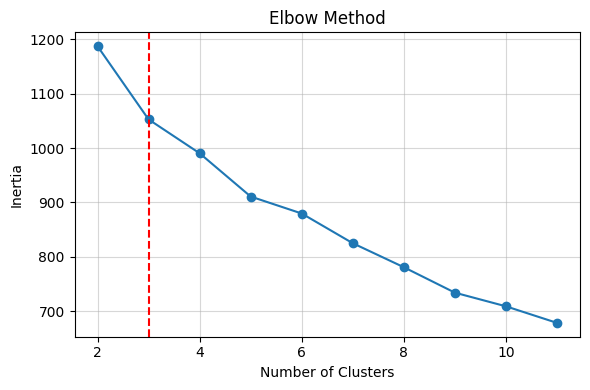

In [16]:
inertia = []

k_range = range(2, 12)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.axvline(3,ls="--",color="r")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.savefig("../reports/figures/plot_16_elbow.png", dpi=150)
plt.show()

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_ml['cluster'] = kmeans.fit_predict(X_scaled)

In [18]:
cluster_profile = df_ml.groupby('cluster')[feature_cols].mean()
print(cluster_profile)

         impulse_composite_score  pct_unplanned_avg  avg_weekly_tx  \
cluster                                                              
0                       1.594697          35.454545      10.045455   
1                       2.250000          65.000000      15.750000   
2                       1.931452          33.870968       9.161290   

         regret_frequency  balance_check_habit  ran_out_of_money  \
cluster                                                            
0                1.090909             1.606061          1.166667   
1                2.000000             1.625000          2.750000   
2                1.000000             1.774194          1.516129   

         hidden_purchase  tracks_expenses  flag_morning  flag_afternoon  \
cluster                                                                   
0               0.969697         1.121212      0.030303        0.136364   
1               1.750000         0.750000      0.500000        0.500000   
2       

In [19]:
df.loc[df_ml.index, 'cluster'] = df_ml['cluster']
cluster_names = {
    0: "Routine Evening Spenders",
    1: "High Impulsive Spenders",
    2: "Controlled Spenders"
}

df['cluster_name'] = df['cluster'].map(cluster_names)

df[['cluster', 'cluster_name']].drop_duplicates()

df['cluster_name'].value_counts()

cluster_name
Routine Evening Spenders    66
Controlled Spenders         31
High Impulsive Spenders      8
Name: count, dtype: int64

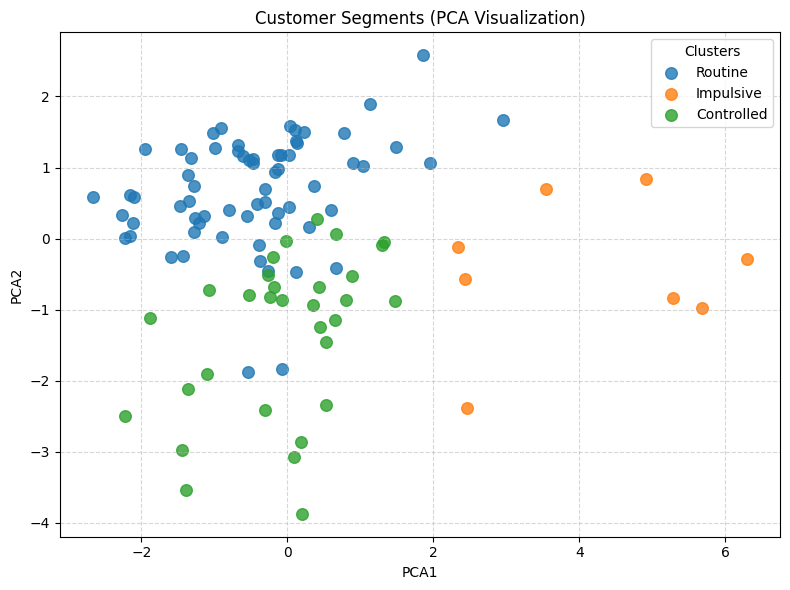

In [20]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

palette = {
    0: "#4C72B0",
    1: "#DD8452",
    2: "#55A868" 
}

label_map = {
    0: "Routine",
    1: "Impulsive",
    2: "Controlled"
}

for cluster in sorted(df_ml['cluster'].unique()):
    subset = df_ml[df_ml['cluster'] == cluster]
    plt.scatter(
        X_pca[subset.index, 0],
        X_pca[subset.index, 1],
        label = label_map[cluster],
        s=70,
        alpha=0.8,
    )

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Customer Segments (PCA Visualization)")

plt.legend(title="Clusters",)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("../reports/figures/plot_17_cluster_pca.png", dpi=150)

plt.show()

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [22]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6190476190476191

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.79      0.73        14
           1       0.40      0.29      0.33         7

    accuracy                           0.62        21
   macro avg       0.54      0.54      0.53        21
weighted avg       0.59      0.62      0.60        21



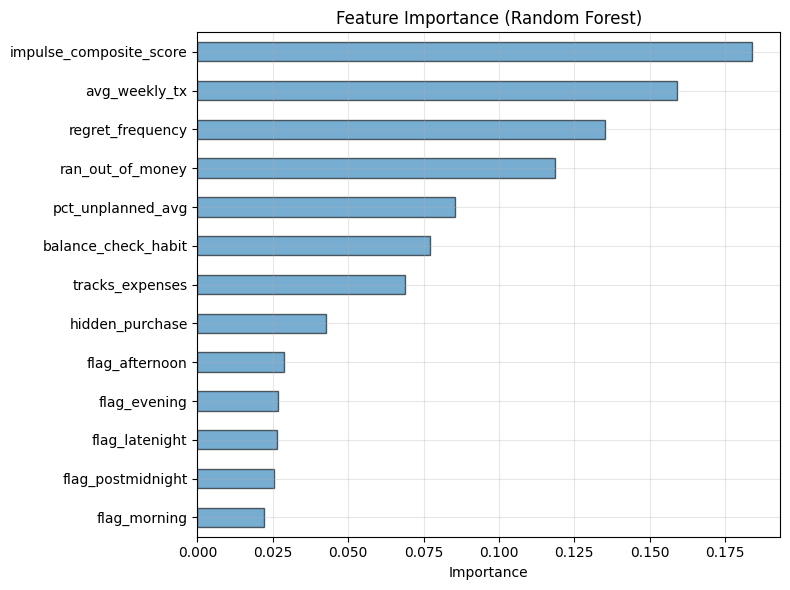

In [24]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values()

plt.figure(figsize=(8,6))
importances.plot(kind='barh',edgecolor="black",alpha=0.6)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")

plt.tight_layout()
plt.grid(alpha= 0.3)
plt.savefig("../reports/figures/plot_18_feature_importance.png", dpi=150)
plt.show()

In [25]:
df.loc[df_ml.index, 'cluster'] = df_ml['cluster']

df.to_csv("../data/processed/combined_with_clusters.csv", index=False)